### Estudo da variabilidade das respostas dos modelos GPT SLR1

Vamos simular as variabilidade das respostas do gpt, olhando os resultados processados diversas vezes para cada modelo.

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import openai
import numpy as np
import time
import os
from dotenv import load_dotenv, find_dotenv
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
### style de execução
tqdm.pandas()

### variaveis de ambiente e conexões

In [3]:
# Carrega as variáveis do arquivo .env
load_dotenv("/data/codigos/.env")

True

In [4]:
for key in os.environ.keys():
    print(f'{key}')

HOSTNAME
HOME
GPG_KEY
PYTHON_SHA256
PATH
LANG
SHELL
PYTHON_VERSION
PWD
VSCODE_CWD
VSCODE_NLS_CONFIG
VSCODE_HANDLES_SIGPIPE
VSCODE_ESM_ENTRYPOINT
VSCODE_HANDLES_UNCAUGHT_ERRORS
REMOTE_CONTAINERS_IPC
REMOTE_CONTAINERS_SOCKETS
SHLVL
_
REMOTE_CONTAINERS
BROWSER
ELECTRON_RUN_AS_NODE
VSCODE_IPC_HOOK_CLI
APPLICATION_INSIGHTS_NO_STATSBEAT
PYDEVD_IPYTHON_COMPATIBLE_DEBUGGING
PYTHONUNBUFFERED
PYTHONIOENCODING
PYTHON_FROZEN_MODULES
PYDEVD_USE_FRAME_EVAL
TERM
CLICOLOR
FORCE_COLOR
CLICOLOR_FORCE
PAGER
GIT_PAGER
MPLBACKEND
KMP_DUPLICATE_LIB_OK
KMP_INIT_AT_FORK
OPENAI_API_KEY_GOV_ANALITICA
GOOGLE_API_KEY_LLMS_PROF_DANILO
ANTROPIC_API_KEY_LLMS
GOOGLE_CLOUD_PROJECT
GOOGLE_CLOUD_REGION


In [5]:
def create_client(key_env):
    """
    Passa a chave do ambiente local para definir a conexao
    """
    client = openai.OpenAI(api_key = os.getenv(key_env))
    return client

In [6]:
client = openai.OpenAI(api_key = os.getenv('OPENAI_API_KEY_GOV_ANALITICA'))

# LLMs da Openai
-----

### Leitura dos arquivos

In [7]:
df_slr1 = pd.read_excel("/data/codigos/dados/titulo_resumo_palavras_slr1_v2.xlsx",engine='openpyxl')
df_slr1.head()

,ID,Title,resumo,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado
2,slr1_3,Machine learning\n based cognitive skills cal...,Advance measurement of cognitive skills of a h...,"Cognitive skills, Computational Intelligence,H...",sucesso,sucesso,não,não estruturado
3,slr1_4,Human Factors_x000D_\n Engineering in Interac...,This paper presents a systematic review of tec...,"Urban planning,Virtual reality,Mixed reality,A...",sucesso,sucesso,não,não estruturado
4,slr1_5,Empirical comparisons_x000D_\n for combining ...,The process of modelling individual player per...,"Class imbalance, data mining, data sampling, f...",sucesso,sucesso,não,não estruturado


In [8]:
df_slr1 = df_slr1.replace({r'_x000D_|\n': ''}, regex=True)

In [9]:
df_slr1.head()

,ID,Title,resumo,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado
2,slr1_3,Machine learning based cognitive skills calcu...,Advance measurement of cognitive skills of a h...,"Cognitive skills, Computational Intelligence,H...",sucesso,sucesso,não,não estruturado
3,slr1_4,Human Factors Engineering in Interactive Urba...,This paper presents a systematic review of tec...,"Urban planning,Virtual reality,Mixed reality,A...",sucesso,sucesso,não,não estruturado
4,slr1_5,Empirical comparisons for combining balancing...,The process of modelling individual player per...,"Class imbalance, data mining, data sampling, f...",sucesso,sucesso,não,não estruturado


#### Limpeza dos casos em que não conseguimos extrair as informações


In [10]:
# Calcula a quantidade de valores por nível no campo "sucesso_fracasso"
sucesso_fracasso_counts = df_slr1['sucesso_fracasso_resumo'].value_counts()
print(sucesso_fracasso_counts)

sucesso_fracasso_resumo
sucesso     132
fracasso      2
Name: count, dtype: int64


In [11]:
# Calcula a quantidade de valores por nível no campo "sucesso_fracasso"
sucesso_fracasso_counts2 = df_slr1['sucesso_fracasso_palavras'].value_counts()
print(sucesso_fracasso_counts2)

sucesso_fracasso_palavras
sucesso     126
fracasso      8
Name: count, dtype: int64


In [12]:
# aqui precisamos, para reproduzir o artigo que ambos os campos tenho informação
df_slr1_clear = df_slr1.loc[((df_slr1['sucesso_fracasso_resumo'].isin(['sucesso']))&(df_slr1['sucesso_fracasso_palavras'].isin(['sucesso'])))].copy()
df_slr1_clear.shape

(126, 8)

In [13]:
print(df_slr1_clear["sucesso_fracasso_resumo"].value_counts())
print(df_slr1_clear["sucesso_fracasso_palavras"].value_counts())

sucesso_fracasso_resumo
sucesso    126
Name: count, dtype: int64
sucesso_fracasso_palavras
sucesso    126
Name: count, dtype: int64


In [14]:
print("Shape antes da limpeza: "+str(df_slr1.shape))
print("Shape depois da limpeza"+str(df_slr1_clear.shape))

Shape antes da limpeza: (134, 8)
Shape depois da limpeza(126, 8)


In [15]:
# Renomear as colunas do dataframe df_slr1_clear
df_slr1_clear.rename(columns={"Title": "title", "resumo": "abstract"}, inplace=True)
df_slr1_clear.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado


### Seleção usando o GPT

In [16]:
def process_selection_with_gpt(model_gpt, title, abstract, keywords,inclusion_criteria_question,client):
    """
    realiza a seleção dos artigos usando a escala likert, conforme o artigo original
    """
    
    # Contexto final para responder as perguntas
    system_message = {
        "role": "system", 
        "content": """Assume you are a software engineering researcher. 
        Conducting a systematic literature review (SLR). Consider the title, abstract and keywords of a primary study"""
    }

    # Prompt final com as perguntas

    # Prompt final com as perguntas, aprimorado para o último bloco
    user_message = { "role": "user",
                     "content": f"""Using a 1-7 Likert scale (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree, 
                    4 - Neither agree nor disagree, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree) 
                    rate your agreement with the question (only number, not symbols or letters):  
                    {inclusion_criteria_question}. About the article: 
                    Title: {title}\n Abstract: {abstract}\n Keywords: {keywords}"""
                    }

   
    # Criação da chamada para a API
    response = client.chat.completions.create(
        model=model_gpt,
        messages=[system_message, user_message],
        temperature=0,
        max_tokens=1,
        top_p=0.1
    )

    try:
        resposta = int(response.choices[0].message.content)
    except Exception as e:
        resposta = response.choices[0].message.content
        print("Erro ao processar:", e)
        print(str(response.choices[0].message.content))
        print(str(title))

    return resposta

In [ ]:
model_gpt1 = "gpt-4.1"
title1 = df_slr1_clear['title'].iloc[34]
abstract1 =  df_slr1_clear['abstract'].iloc[34]
keywords1 = df_slr1_clear['keywords'].iloc[34]
inclusion_criteria_question1 =  """The article discusses the relationship between game
 elements and user types."""

process_selection_with_gpt(model_gpt = model_gpt1,
                          title = title1,
                          abstract = abstract1,
                          keywords=keywords1,
                          inclusion_criteria_question = inclusion_criteria_question1,
                          client=client)


In [17]:
def repeat_selection_with_gpt(df, model_gpt, inclusion_criteria_question, client,n_interactions,name_ic):
    """
    Repete o processo de seleção para todos os registros do dataframe
    """
    for i in range(n_interactions):
        print(i)
        coluna_aux = model_gpt+"_"+name_ic+"_"+str(i)
        temp_filename = f"/data/codigos/dados/resultados/temps/temp_slr1_{model_gpt}_{name_ic}_iter_{i}_v2.xlsx"
        df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_gpt(model_gpt,
                                                                                    row['title'],
                                                                                    row['abstract'],
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    client), axis=1)
         # salvando para nao perder
        df.to_excel(temp_filename, index=False)
    return df

#### Modelo: "gpt-4o"

In [18]:
df_gpt_4o  = df_slr1_clear.copy()
df_gpt_4o.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado


In [19]:
n_interactions = 5  # fixemos em 10 vezes devido ao custo

In [20]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4o" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
df_gpt_4o = repeat_selection_with_gpt(df = df_gpt_4o,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

0


100%|██████████| 126/126 [01:34<00:00,  1.33it/s]


1


100%|██████████| 126/126 [01:30<00:00,  1.39it/s]


2


100%|██████████| 126/126 [01:32<00:00,  1.36it/s]


3


100%|██████████| 126/126 [01:35<00:00,  1.32it/s]


4


100%|██████████| 126/126 [01:28<00:00,  1.42it/s]


In [21]:
df_gpt_4o.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gpt-4o_IC1_0,gpt-4o_IC1_1,gpt-4o_IC1_2,gpt-4o_IC1_3,gpt-4o_IC1_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,4,4,4,5,4


In [22]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4o" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
df_gpt_4o = repeat_selection_with_gpt(df = df_gpt_4o,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

0


100%|██████████| 126/126 [01:26<00:00,  1.45it/s]


1


100%|██████████| 126/126 [01:22<00:00,  1.53it/s]


2


100%|██████████| 126/126 [01:25<00:00,  1.47it/s]


3


100%|██████████| 126/126 [01:30<00:00,  1.40it/s]


4


100%|██████████| 126/126 [01:30<00:00,  1.39it/s]


In [23]:
df_gpt_4o.head()

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gpt-4o_IC1_0,gpt-4o_IC1_1,gpt-4o_IC1_2,gpt-4o_IC1_3,gpt-4o_IC1_4,gpt-4o_IC2_0,gpt-4o_IC2_1,gpt-4o_IC2_2,gpt-4o_IC2_3,gpt-4o_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,5,5,5,5,5
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,4,4,4,5,4,3,3,1,3,3
2,slr1_3,Machine learning based cognitive skills calcu...,Advance measurement of cognitive skills of a h...,"Cognitive skills, Computational Intelligence,H...",sucesso,sucesso,não,não estruturado,3,3,3,3,3,5,5,5,5,5
3,slr1_4,Human Factors Engineering in Interactive Urba...,This paper presents a systematic review of tec...,"Urban planning,Virtual reality,Mixed reality,A...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,3,3,3,3,3
4,slr1_5,Empirical comparisons for combining balancing...,The process of modelling individual player per...,"Class imbalance, data mining, data sampling, f...",sucesso,sucesso,não,não estruturado,3,3,3,3,3,3,3,3,3,1


#### Modelo "gpt-3.5-turbo"

In [26]:
df_gpt_3_5  = df_slr1_clear.copy()
df_gpt_3_5.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado


In [27]:
n_interactions = 5  # fixemos em 10 vezes devido ao custo

In [28]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-3.5-turbo" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """TIt is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
df_gpt_3_5 = repeat_selection_with_gpt(df = df_gpt_3_5,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

0


100%|██████████| 126/126 [01:10<00:00,  1.77it/s]


1


100%|██████████| 126/126 [01:22<00:00,  1.52it/s]


2


100%|██████████| 126/126 [02:48<00:00,  1.34s/it]


3


100%|██████████| 126/126 [01:41<00:00,  1.24it/s]


4


100%|██████████| 126/126 [01:12<00:00,  1.73it/s]


In [29]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-3.5-turbo" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
df_gpt_3_5 = repeat_selection_with_gpt(df = df_gpt_3_5,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

0


100%|██████████| 126/126 [01:13<00:00,  1.71it/s]


1


100%|██████████| 126/126 [01:11<00:00,  1.77it/s]


2


100%|██████████| 126/126 [01:23<00:00,  1.51it/s]


3


100%|██████████| 126/126 [01:14<00:00,  1.70it/s]


4


100%|██████████| 126/126 [01:14<00:00,  1.70it/s]


### Modelo "gpt-4.1"

In [32]:
df_gpt_4_1  = df_slr1_clear.copy()
df_gpt_4_1.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado


In [33]:
df_gpt_4_1.iloc[34, ]

ID                                                                     slr1_37
title                        Speech Difficulties  and Clarification: A Syst...
abstract                     Natural language processing helps the computer...
keywords                      Machine Learning, Speech Clarification,De-noi...
sucesso_fracasso_resumo                                                sucesso
sucesso_fracasso_palavras                                              sucesso
segunda_coleta                                                             não
obs                                                            não estruturado
Name: 36, dtype: object

In [34]:
n_interactions = 5  # fixemos em 10 vezes devido ao custo

In [35]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4.1" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
df_gpt_4_1 = repeat_selection_with_gpt(df = df_gpt_4_1,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

0


100%|██████████| 126/126 [01:26<00:00,  1.45it/s]


1


100%|██████████| 126/126 [01:29<00:00,  1.41it/s]


2


100%|██████████| 126/126 [01:19<00:00,  1.59it/s]


3


100%|██████████| 126/126 [01:23<00:00,  1.50it/s]


4


100%|██████████| 126/126 [01:20<00:00,  1.56it/s]


In [36]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4.1" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
df_gpt_4_1 = repeat_selection_with_gpt(df = df_gpt_4_1,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

0


100%|██████████| 126/126 [01:23<00:00,  1.51it/s]


1


100%|██████████| 126/126 [01:23<00:00,  1.50it/s]


2


100%|██████████| 126/126 [01:22<00:00,  1.52it/s]


3


100%|██████████| 126/126 [01:25<00:00,  1.47it/s]


4


100%|██████████| 126/126 [01:29<00:00,  1.41it/s]


### Gravação

#### gpt 3.5 -turbo

In [30]:
df_gpt_3_5.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gpt-3.5-turbo_IC1_0,gpt-3.5-turbo_IC1_1,gpt-3.5-turbo_IC1_2,gpt-3.5-turbo_IC1_3,gpt-3.5-turbo_IC1_4,gpt-3.5-turbo_IC2_0,gpt-3.5-turbo_IC2_1,gpt-3.5-turbo_IC2_2,gpt-3.5-turbo_IC2_3,gpt-3.5-turbo_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,4,4,7,7,7,6,7,7,6,7
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,4,4,4,4,4,6,6,6,6,6


In [31]:
# grava os resultados
df_gpt_3_5.to_excel("/data/codigos/dados/resultados/reproducao_resultados_openai_gpt_35_slr1_v2.xlsx", index=False)
df_gpt_3_5.to_csv("/data/codigos/dados/resultados/reproducao_resultados_openai_gpt_35_slr1_v2.csv", encoding='utf-8', index=False)

#### gpt 4o

In [24]:
df_gpt_4o.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gpt-4o_IC1_0,gpt-4o_IC1_1,gpt-4o_IC1_2,gpt-4o_IC1_3,gpt-4o_IC1_4,gpt-4o_IC2_0,gpt-4o_IC2_1,gpt-4o_IC2_2,gpt-4o_IC2_3,gpt-4o_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,5,5,5,5,5
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,4,4,4,5,4,3,3,1,3,3


In [25]:
# grava os resultados
df_gpt_4o.to_excel("/data/codigos/dados/resultados/reproducao_resultados_openai_gpt_4o_slr1_v2.xlsx", index=False)
df_gpt_4o.to_csv("/data/codigos/dados/resultados/reproducao_resultados_openai_gpt_4o_slr1_v2.csv", encoding='utf-8', index=False)

#### gpt-4.1

In [37]:
df_gpt_4_1.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gpt-4.1_IC1_0,gpt-4.1_IC1_1,gpt-4.1_IC1_2,gpt-4.1_IC1_3,gpt-4.1_IC1_4,gpt-4.1_IC2_0,gpt-4.1_IC2_1,gpt-4.1_IC2_2,gpt-4.1_IC2_3,gpt-4.1_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,6,6,6,6,6
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,6,6,6,6,6,4,4,4,4,3


In [38]:
# grava os resultados
df_gpt_4_1.to_excel("/data/codigos/dados/resultados/reproducao_resultados_openai_gpt_41_slr1_v2.xlsx", index=False)
df_gpt_4_1.to_csv("/data/codigos/dados/resultados/reproducao_resultados_openai_gpt_41_slr1_v2.csv", encoding='utf-8', index=False)

## Analise dos resultados

### Leitura dos resultados processados

In [39]:
df_gpt3 = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_openai_gpt_35_slr1_v2.csv",encoding='utf-8')
df_gpt3.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gpt-3.5-turbo_IC1_0,gpt-3.5-turbo_IC1_1,gpt-3.5-turbo_IC1_2,gpt-3.5-turbo_IC1_3,gpt-3.5-turbo_IC1_4,gpt-3.5-turbo_IC2_0,gpt-3.5-turbo_IC2_1,gpt-3.5-turbo_IC2_2,gpt-3.5-turbo_IC2_3,gpt-3.5-turbo_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,4,4,7,7,7,6,7,7,6,7
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,4,4,4,4,4,6,6,6,6,6


In [40]:
df_gpt4 = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_openai_gpt_4o_slr1_v2.csv",encoding='utf-8')
df_gpt4.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gpt-4o_IC1_0,gpt-4o_IC1_1,gpt-4o_IC1_2,gpt-4o_IC1_3,gpt-4o_IC1_4,gpt-4o_IC2_0,gpt-4o_IC2_1,gpt-4o_IC2_2,gpt-4o_IC2_3,gpt-4o_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,5,5,5,5,5
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,4,4,4,5,4,3,3,1,3,3


In [41]:
df_gpt41 = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_openai_gpt_41_slr1_v2.csv",encoding='utf-8')
df_gpt41.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gpt-4.1_IC1_0,gpt-4.1_IC1_1,gpt-4.1_IC1_2,gpt-4.1_IC1_3,gpt-4.1_IC1_4,gpt-4.1_IC2_0,gpt-4.1_IC2_1,gpt-4.1_IC2_2,gpt-4.1_IC2_3,gpt-4.1_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,6,6,6,6,6
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,6,6,6,6,6,4,4,4,4,3


In [42]:
# vamos trazer os dados disponibilizados pelos autores para comparação de performance
df_slr1_autores = pd.read_excel("/data/codigos/dados/SLR1-results-keys.xlsx",engine='openpyxl')
df_slr1_autores.head()

,ID,Title,IC1,IC2,Benchmark,Execution time (s),Total Tokens
0,slr1_1,User Experience_x000D_\n Design Using Machine...,7.0,6.0,I,1.321527,955.0
1,slr1_2,Sentiment analysis_x000D_\n on arabic tweets:...,7.0,4.0,E,0.922849,707.0
2,slr1_3,Machine learning_x000D_\n based cognitive ski...,7.0,6.0,E,1.285468,705.0
3,slr1_4,Human Factors_x000D_\n Engineering in Interac...,7.0,4.0,E,1.144713,783.0
4,slr1_5,Empirical comparisons_x000D_\n for combining ...,1.0,4.0,E,1.152106,1327.0


In [43]:
df_gpt3 = pd.merge(left=df_gpt3, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_gpt3.shape


(126, 21)

In [44]:
df_gpt4 = pd.merge(left=df_gpt4, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_gpt4.shape

(126, 21)

In [45]:
df_gpt41 = pd.merge(left=df_gpt41, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_gpt41.shape

(126, 21)

In [46]:
print("df_gpt3: "+str(df_gpt3.shape))
print("df_gpt4: "+str(df_gpt4.shape))
print("df_gpt41: "+str(df_gpt41.shape))
print("df_slr1_autores: "+str(df_slr1_autores.shape))


df_gpt3: (126, 21)
df_gpt4: (126, 21)
df_gpt41: (126, 21)
df_slr1_autores: (135, 7)


### Geração dos resultados das llms e padronizacao dos campos

In [47]:
# criando a regra do corte em 5
def convert_benchmark(df,col1):
    df["result_bench"] = np.where(df[col1].str.lower()=="i",1,0)
    return df

In [48]:
df_gpt3 = convert_benchmark(df_gpt3,"Benchmark")

In [49]:
df_gpt4 = convert_benchmark(df_gpt4,"Benchmark")

In [50]:
df_gpt41 = convert_benchmark(df_gpt41,"Benchmark")

In [51]:
def create_result_llm_classic(df,col1,col2,limit1,limit2,col_name):
    """
    Create flag with result for llms
    """
    df["aux_ic1"] = np.where(df[col1]>=limit1,1,0)
    df["aux_ic2"] = np.where(df[col2]>=limit2,1,0)
    df[col_name] = np.where(((df["aux_ic1"]==1) & (df["aux_ic2"]==1)),1,0)
    return df.drop(columns=["aux_ic1","aux_ic2"])

In [52]:
df_gpt3.head(1)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gpt-3.5-turbo_IC1_0,gpt-3.5-turbo_IC1_1,...,gpt-3.5-turbo_IC1_4,gpt-3.5-turbo_IC2_0,gpt-3.5-turbo_IC2_1,gpt-3.5-turbo_IC2_2,gpt-3.5-turbo_IC2_3,gpt-3.5-turbo_IC2_4,IC1,IC2,Benchmark,result_bench
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,4,4,...,7,6,7,7,6,7,7.0,6.0,I,1


In [53]:
# Cria a resposta final para cada iteração
def calculate_select_result_llm(n_interactions, model_gpt, df):
    name_ic1 = "IC1"
    name_ic2 = "IC2"
    for i in range(n_interactions):
        coluna_aux1 = model_gpt+"_"+name_ic1+"_"+str(i)
        coluna_aux2 = model_gpt+"_"+name_ic2+"_"+str(i)
        col_name = model_gpt+"_"+str(i)
        df = create_result_llm_classic(df=df,
                                        col1=coluna_aux1,
                                        col2=coluna_aux2,
                                        limit1=5,
                                        limit2=5,
                                        col_name=col_name)
    return df

In [54]:
n_interactions = 5
model_gpt = "gpt-3.5-turbo"
df_gpt3 = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_gpt3)

In [55]:
df_gpt3.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gpt-3.5-turbo_IC1_0,gpt-3.5-turbo_IC1_1,...,gpt-3.5-turbo_IC2_4,IC1,IC2,Benchmark,result_bench,gpt-3.5-turbo_0,gpt-3.5-turbo_1,gpt-3.5-turbo_2,gpt-3.5-turbo_3,gpt-3.5-turbo_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,4,4,...,7,7.0,6.0,I,1,0,0,1,1,1
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,4,4,...,6,7.0,4.0,E,0,0,0,0,0,0


In [56]:
n_interactions = 5
model_gpt = "gpt-4o"
df_gpt4 = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_gpt4)

In [57]:
n_interactions = 5
model_gpt = "gpt-4.1"
df_gpt41 = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_gpt41)

### Analises de performance

In [58]:
def calculate_accuracy(n_interactions, model_gpt, df, col_benchmark):
    """
    Calcula a acurácia para cada iteração e armazena os resultados em um dataframe.
    
    Parâmetros:
    n_interactions (int): Número de interações.
    model_gpt (str): Nome do modelo GPT.
    df (pd.DataFrame): DataFrame contendo os dados.
    col_benchmark (str): Nome da coluna de benchmark.
    
    Retorna:
    pd.DataFrame: DataFrame com as colunas 'Model_Iteration' e 'Accuracy'.
    """
    accuracy_results = []

    for i in range(n_interactions):
        col_name = model_gpt + "_" + str(i)
        accuracy = accuracy_score(df[col_benchmark], df[col_name])
        accuracy_results.append({'Model_Iteration': col_name, 'Accuracy': accuracy})

    return pd.DataFrame(accuracy_results)


In [59]:
n_interactions = 5
model_gpt = "gpt-3.5-turbo"
df_result_gpt3 = calculate_accuracy(n_interactions=n_interactions,
                                    model_gpt=model_gpt,
                                    df=df_gpt3, 
                                    col_benchmark='result_bench')
df_result_gpt3

,Model_Iteration,Accuracy
0,gpt-3.5-turbo_0,0.619048
1,gpt-3.5-turbo_1,0.634921
2,gpt-3.5-turbo_2,0.682540
3,gpt-3.5-turbo_3,0.698413
4,gpt-3.5-turbo_4,0.626984


In [60]:
n_interactions = 5
model_gpt = "gpt-4o"
df_result_gpt4 = calculate_accuracy(n_interactions=n_interactions,
                                    model_gpt=model_gpt,
                                    df=df_gpt4, 
                                    col_benchmark='result_bench')
df_result_gpt4

,Model_Iteration,Accuracy
0,gpt-4o_0,0.809524
1,gpt-4o_1,0.865079
2,gpt-4o_2,0.801587
3,gpt-4o_3,0.849206
4,gpt-4o_4,0.825397


In [61]:
n_interactions = 5
model_gpt = "gpt-4.1"
df_result_gpt41 = calculate_accuracy(n_interactions=n_interactions,
                                    model_gpt=model_gpt,
                                    df=df_gpt41, 
                                    col_benchmark='result_bench')
df_result_gpt41

,Model_Iteration,Accuracy
0,gpt-4.1_0,0.769841
1,gpt-4.1_1,0.785714
2,gpt-4.1_2,0.777778
3,gpt-4.1_3,0.785714
4,gpt-4.1_4,0.777778


In [62]:
def graph_scatter_plot(df,col_values,col_name_models,title_graph,xlabel,ylabel,ylim_flag,ylim):
    # Supondo que df seja o dataframe com as colunas "Model_Iteration" e "Accuracy"
    # Calcular a média e o desvio padrão da acurácia
    mean_accuracy = df[col_values].mean()
    std_accuracy = df[col_values].std()

    # Configurar o tamanho da figura
    plt.figure(figsize=(12, 6))

    # Criar o scatterplot
    plt.scatter(df[col_name_models], df[col_values], color='royalblue', label='Accuracy')

    # Adicionar linhas horizontais para a média e os limites inferior e superior
    plt.axhline(y=mean_accuracy, color='darkblue', linestyle='-', label='Mean Accuracy')
    plt.axhline(y=mean_accuracy - std_accuracy, color='cornflowerblue', linestyle='--', label='Mean - Std Dev')
    plt.axhline(y=mean_accuracy + std_accuracy, color='cornflowerblue', linestyle='--', label='Mean + Std Dev')

    # Adicionar título e nomes nos eixos
    plt.title(title_graph)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # Adicionar legenda
    plt.legend()

    # limite
    if ylim_flag:
        plt.ylim(ylim)

    # Rotacionar os rótulos do eixo x para melhor visualização
    plt.xticks(rotation=45)

    # Exibir o gráfico
    plt.tight_layout()
    
    # Remover bordas desnecessárias
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.show()



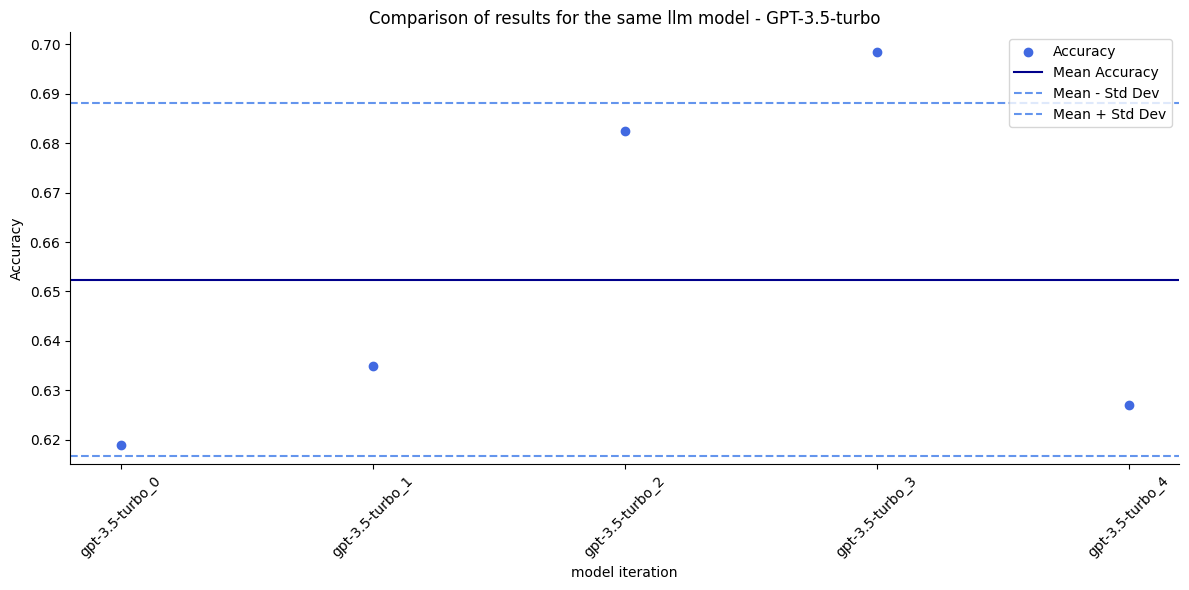

In [63]:
graph_scatter_plot(df = df_result_gpt3,
                    col_values = "Accuracy",
                    col_name_models = "Model_Iteration",
                    title_graph = "Comparison of results for the same llm model - GPT-3.5-turbo",
                    xlabel = "model iteration",
                    ylabel = "Accuracy",
                    ylim_flag=False,
                    ylim=[0.50,0.8])

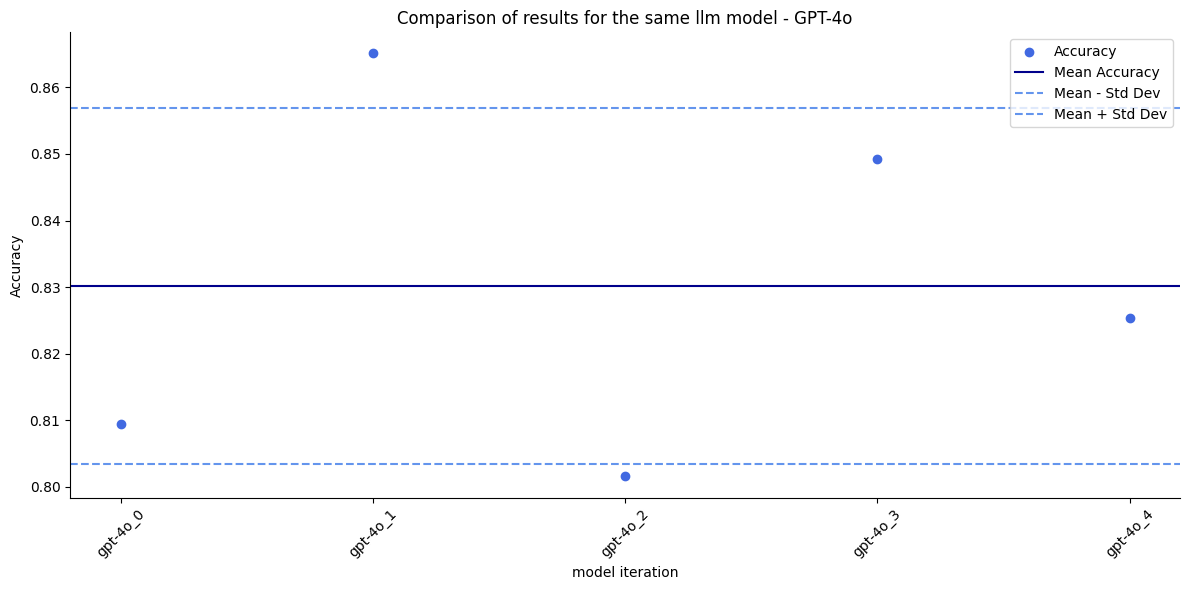

In [64]:
graph_scatter_plot(df = df_result_gpt4,
                    col_values = "Accuracy",
                    col_name_models = "Model_Iteration",
                    title_graph = "Comparison of results for the same llm model - GPT-4o",
                    xlabel = "model iteration",
                    ylabel = "Accuracy",
                    ylim_flag=False,
                    ylim=[0.50,0.8])

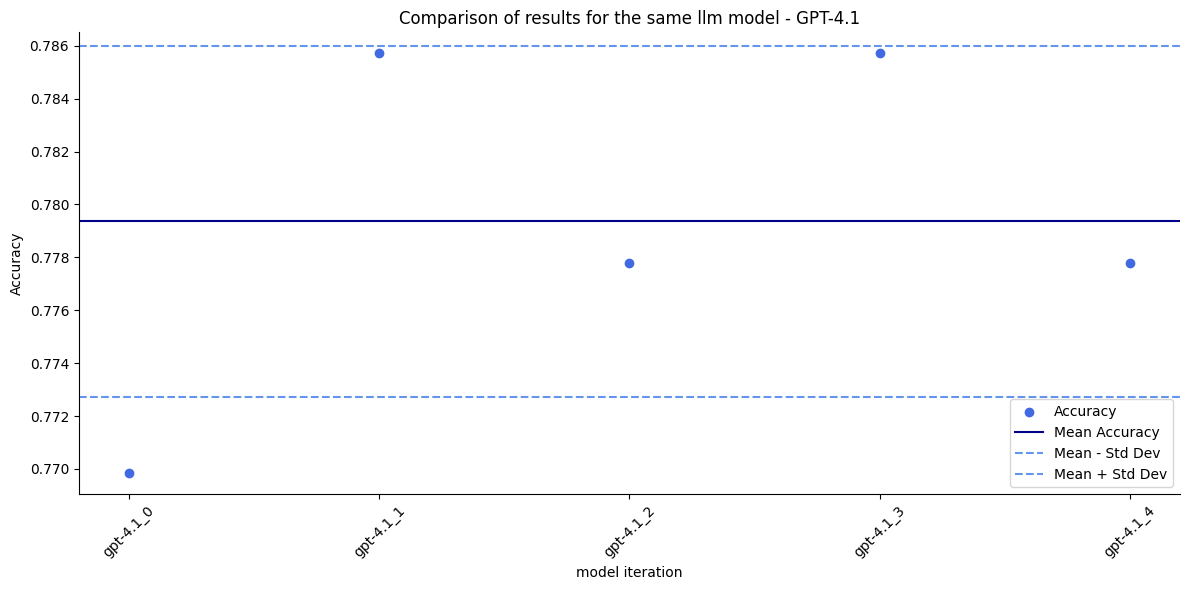

In [65]:
graph_scatter_plot(df = df_result_gpt41,
                    col_values = "Accuracy",
                    col_name_models = "Model_Iteration",
                    title_graph = "Comparison of results for the same llm model - GPT-4.1",
                    xlabel = "model iteration",
                    ylabel = "Accuracy",
                    ylim_flag=False,
                    ylim=[0.50,0.9])

Nota-se que para modelos mais avançados a variabilidade é menor, indicando estabilização mais rápida.

In [66]:
### Grava os resultados finais
df_result_gpt3.to_excel("/data/codigos/dados/resultados/reproducao_acuracia_openai_gpt_35_final_srl1_v2.xlsx", index=False)
df_result_gpt3.to_csv("/data/codigos/dados/resultados/reproducao_acuracia_openai_gpt_35_final_srl1_v2.csv", encoding='utf-8', index=False)

df_result_gpt4.to_excel("/data/codigos/dados/resultados/reproducao_acuracia_openai_gpt_4_final_srl1_v2.xlsx", index=False)
df_result_gpt4.to_csv("/data/codigos/dados/resultados/reproducao_acuracia_openai_gpt_4_final_srl1_v2.csv", encoding='utf-8', index=False)

df_result_gpt41.to_excel("/data/codigos/dados/resultados/reproducao_acuracia_openai_gpt_41_final_srl1_v2.xlsx", index=False)
df_result_gpt41.to_csv("/data/codigos/dados/resultados/reproducao_acuracia_openai_gpt_41_final_srl1_v2.csv", encoding='utf-8', index=False)

### Comparativo geral da Openai

In [67]:
df_result_gpt3.head(2)

,Model_Iteration,Accuracy
0,gpt-3.5-turbo_0,0.619048
1,gpt-3.5-turbo_1,0.634921


In [68]:
df_result_gpt3["iteration"] = df_result_gpt3["Model_Iteration"].str.extract(r'_(\d+)$')[0].astype(int)
df_result_gpt3["model"] = "gpt-3.5-turbo"
df_result_gpt3

,Model_Iteration,Accuracy,iteration,model
0,gpt-3.5-turbo_0,0.619048,0,gpt-3.5-turbo
1,gpt-3.5-turbo_1,0.634921,1,gpt-3.5-turbo
2,gpt-3.5-turbo_2,0.682540,2,gpt-3.5-turbo
3,gpt-3.5-turbo_3,0.698413,3,gpt-3.5-turbo
4,gpt-3.5-turbo_4,0.626984,4,gpt-3.5-turbo


In [69]:
df_result_gpt4["iteration"] = df_result_gpt4["Model_Iteration"].str.extract(r'_(\d+)$')[0].astype(int)
df_result_gpt4["model"] = "gpt-4o"
df_result_gpt4

,Model_Iteration,Accuracy,iteration,model
0,gpt-4o_0,0.809524,0,gpt-4o
1,gpt-4o_1,0.865079,1,gpt-4o
2,gpt-4o_2,0.801587,2,gpt-4o
3,gpt-4o_3,0.849206,3,gpt-4o
4,gpt-4o_4,0.825397,4,gpt-4o


In [70]:
df_result_gpt41["iteration"] = df_result_gpt41["Model_Iteration"].str.extract(r'_(\d+)$')[0].astype(int)
df_result_gpt41["model"] = "gpt-4.1"
df_result_gpt41

,Model_Iteration,Accuracy,iteration,model
0,gpt-4.1_0,0.769841,0,gpt-4.1
1,gpt-4.1_1,0.785714,1,gpt-4.1
2,gpt-4.1_2,0.777778,2,gpt-4.1
3,gpt-4.1_3,0.785714,3,gpt-4.1
4,gpt-4.1_4,0.777778,4,gpt-4.1


In [71]:
# concatena os dataframes
df_results = pd.concat([df_result_gpt3, df_result_gpt4, df_result_gpt41], ignore_index=True)
df_results.head(2)

,Model_Iteration,Accuracy,iteration,model
0,gpt-3.5-turbo_0,0.619048,0,gpt-3.5-turbo
1,gpt-3.5-turbo_1,0.634921,1,gpt-3.5-turbo


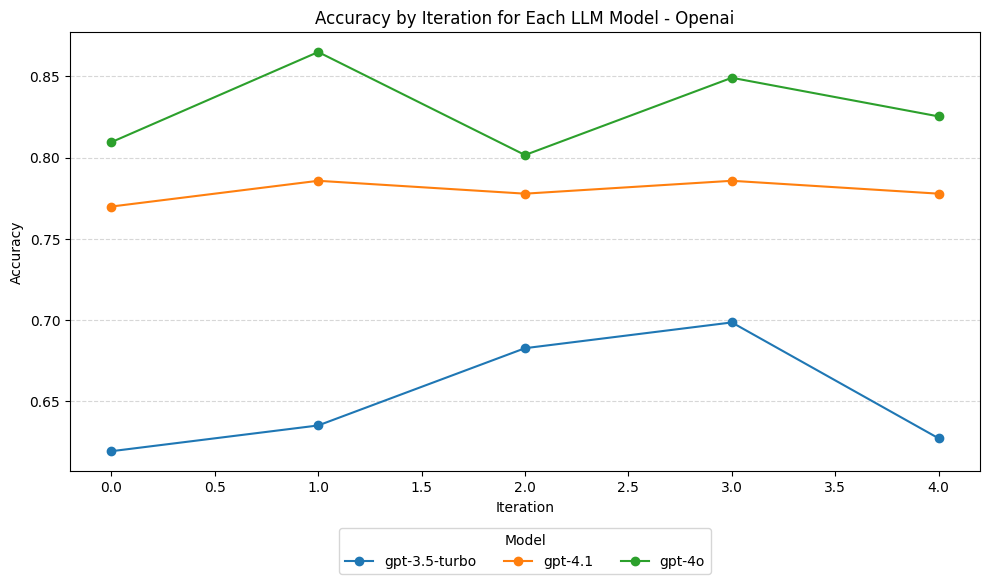

In [72]:
plt.figure(figsize=(10, 6))

for model_name, group in df_results.groupby("model"):
    plt.plot(group["iteration"], group["Accuracy"], marker='o', label=model_name)

plt.title("Accuracy by Iteration for Each LLM Model - Openai")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.legend(title="Model", loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [73]:
df_results.head(2)

,Model_Iteration,Accuracy,iteration,model
0,gpt-3.5-turbo_0,0.619048,0,gpt-3.5-turbo
1,gpt-3.5-turbo_1,0.634921,1,gpt-3.5-turbo


In [74]:
summary_stats = df_results.groupby('model')['Accuracy'].agg(['mean', 'std'])
summary_stats

,mean,std
model,,
gpt-3.5-turbo,0.652381,0.035670
gpt-4.1,0.779365,0.006640
gpt-4o,0.830159,0.026679


In [75]:
summary_stats["model"] = summary_stats.index
summary_stats = summary_stats.reset_index(drop=True)
summary_stats["ic_lower"] = summary_stats["mean"] - summary_stats["std"]
summary_stats["ic_upper"] = summary_stats["mean"] + summary_stats["std"]
summary_stats

,mean,std,model,ic_lower,ic_upper
0,0.652381,0.035670,gpt-3.5-turbo,0.616711,0.688051
1,0.779365,0.006640,gpt-4.1,0.772725,0.786005
2,0.830159,0.026679,gpt-4o,0.803480,0.856838
